In [1]:
!git clone https://github.com/karolpiczak/ESC-50.git

fatal: destination path 'ESC-50' already exists and is not an empty directory.


In [2]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

### 1. Upload do Dataset

In [3]:
caminho_csv = 'ESC-50/meta/esc50.csv'
PASTA_AUDIO = 'ESC-50/audio/'

In [4]:
df_original = pd.read_csv(caminho_csv)

Categorias
Animais (Índices 0 a 9)
0: Dog / 1: Rooster / 2: Pig / 3: Cow / 4: Frog / 5: Cat / 6: Hen / 7: Insects (flying) / 8: Sheep / 9: Crow

 Paisagens Naturais e Sons de Água (Índices 10 a 19)
 10: Rain / 11: Sea waves / 12: Crackling fire / 13: Crickets / 14: Chirping birds / 15: Water drops / 16: Wind / 17: Pouring water / 18: Toilet flush (Descarga de vaso sanitário) / 19: Thunderstorm (Tempestade com trovoada)

 Ruídos Externos / Urbanos (Índices 40 a 49)
 40: Helicopter / 41: Chainsaw / 42: Siren / 43: Car horn / 44: Engine / 45: Train / 46: Church bells / 47: Airplane / 48: Fireworks / 49: Hand saw

In [5]:
df = df_original[(df_original['target'] <= 19) | (df_original['target'] >= 40)]

In [6]:
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
8,1-103298-A-9.wav,1,9,crow,False,103298,A


In [7]:
df.shape

(1200, 7)

### 2. Ajustes do Dataset

In [8]:
SR = 16000
COLUNA_ARQUIVO = "filename"

In [9]:
def estatisticas(vetor, prefixo):
    """
    Transforma uma série temporal em características por áudio.
    """
    vetor = np.asarray(vetor).flatten()

    return {
        f"{prefixo}_mean": np.mean(vetor),
        f"{prefixo}_std": np.std(vetor),
        f"{prefixo}_median": np.median(vetor),
        f"{prefixo}_min": np.min(vetor),
        f"{prefixo}_max": np.max(vetor),
    }

### 3. Experimento C: A + B

In [10]:
def extrair_experimento_C(caminho,  n_mfcc, sr=SR):

    y, sr = librosa.load(caminho, sr=sr, mono=True)

    features = {}

    # 1. MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                mfcc[i],
                f"mfcc_{i+1}"
            )
        )

    # 2. DELTA
    delta = librosa.feature.delta(mfcc)
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta[i],
                f"delta_{i+1}"
            )
        )

    # 3. DELTA-DELTA
    delta_delta = librosa.feature.delta(
        mfcc,
        order=2
    )
    for i in range(n_mfcc):
        features.update(
            estatisticas(
                delta_delta[i],
                f"delta_delta_{i+1}"
            )
        )

    # 4. ZERO CROSSING RATE
    zcr = librosa.feature.zero_crossing_rate(y)[0]

    features.update(
        estatisticas(
            zcr,
            "zcr"
        )
    )

    # 5. SPECTRAL CENTROID
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )[0]
    features.update(
        estatisticas(
            centroid,
            "centroid"
        )
    )


    # 6. FREQUÊNCIA DOMINANTE
    espectro = np.abs(librosa.stft(y))
    frequencias = librosa.fft_frequencies(sr=sr)
    indice_dominante = np.argmax(
        espectro,
        axis=0
    )
    freq_dominante = frequencias[indice_dominante]
    features.update(estatisticas(freq_dominante, "freq_dominante"))

    # 7. PULSOS POR SEGUNDO
    # Usa onset detection.
    # Cada onset representa aproximadamente um evento/pulso.
    onset_frames = librosa.onset.onset_detect(y=y,sr=sr)
    duracao = librosa.get_duration(y=y, sr=sr)
    if duracao > 0:
        pulsos_por_segundo = len(onset_frames) / duracao
    else:
        pulsos_por_segundo = 0

    features["pulsos_por_segundo"] = pulsos_por_segundo

    # 8. SILÊNCIO
    rms = librosa.feature.rms(y=y)[0]
    threshold = np.max(rms) * 0.05
    frames_silenciosos = rms < threshold
    percentual_silencio = np.mean(
        frames_silenciosos
    )
    features["percentual_silencio"] = percentual_silencio

    # 9. ENTROPIA ESPECTRAL
    potencia = espectro ** 2
    soma = np.sum(
        potencia,
        axis=0,
        keepdims=True
    )

    # evita divisão por zero
    soma[soma == 0] = 1e-12
    probabilidade = potencia / soma

    entropia = entropy(
        probabilidade,
        axis=0
    )
    features.update(
        estatisticas(
            entropia,
            "entropia_espectral"
        )
    )

    # 10. FLUXO ESPECTRAL
    spectral_flux = librosa.onset.onset_strength(
        y=y,
        sr=sr
    )

    features.update(
        estatisticas(
            spectral_flux,
            "fluxo_espectral"
        )
    )

    return features

### 4. Dataframes Finais Gerados

In [11]:
resultados_C = []

for _, linha in df.iterrows():

    arquivo = linha[COLUNA_ARQUIVO]

    caminho = f"{PASTA_AUDIO}/{arquivo}"

    try:

        features_C = extrair_experimento_C(caminho, 5)

        # --------------------------------------------
        # Metadados
        # --------------------------------------------
        features_C["filename"] = arquivo

        # mantém a classe original
        if "target" in df.columns:
            features_C["target"] = linha["target"]

        if "category" in df.columns:
            features_C["category"] = linha["category"]

        resultados_C.append(features_C)

    except Exception as e:

        print(
            f"Erro em {arquivo}: {e}"
        )

In [12]:
df_C = pd.DataFrame(resultados_C)

print("\nExperimento C:")
print(df_C.shape)

print("\nPrimeiras colunas C:")
print(df_C.columns.tolist())


Experimento C:
(1200, 105)

Primeiras colunas C:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_1_min', 'mfcc_1_max', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median', 'mfcc_2_min', 'mfcc_2_max', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_3_median', 'mfcc_3_min', 'mfcc_3_max', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_4_median', 'mfcc_4_min', 'mfcc_4_max', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_5_median', 'mfcc_5_min', 'mfcc_5_max', 'delta_1_mean', 'delta_1_std', 'delta_1_median', 'delta_1_min', 'delta_1_max', 'delta_2_mean', 'delta_2_std', 'delta_2_median', 'delta_2_min', 'delta_2_max', 'delta_3_mean', 'delta_3_std', 'delta_3_median', 'delta_3_min', 'delta_3_max', 'delta_4_mean', 'delta_4_std', 'delta_4_median', 'delta_4_min', 'delta_4_max', 'delta_5_mean', 'delta_5_std', 'delta_5_median', 'delta_5_min', 'delta_5_max', 'delta_delta_1_mean', 'delta_delta_1_std', 'delta_delta_1_median', 'delta_delta_1_min', 'delta_delta_1_max', 'delta_delta_2_mean', 'delta_delta_2_std', 'delta_delta_2_median', 'delta_d

### 6. Análise de Poder Discriminativo com ANOVA/F-Score
    -Quais características mais representam/diferenciam as classes?

In [13]:
# ANÁLISE DE PODER DISCRIMINATIVO

def analisar_atributos(df_features, coluna_classe="target"):

    # somente atributos numéricos
    X = df_features.select_dtypes(
        include=np.number
    ).copy()

    # remove a própria variável target
    if coluna_classe in X.columns:
        X = X.drop(columns=[coluna_classe])

    y = df_features[coluna_classe]

    # remove NaN / infinito
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    mascara = X.notna().all(axis=1)
    X = X[mascara]
    y = y[mascara]

    # F-score ANOVA
    f_scores, p_values = f_classif(
        X,
        y
    )

    resultado = pd.DataFrame({
        "atributo": X.columns,
        "F_score": f_scores,
        "p_value": p_values
    })

    resultado = resultado.sort_values(
        "F_score",
        ascending=False
    )

    return resultado

In [14]:
ranking_C = analisar_atributos(
    df_C,
    "target"
)
print("----------EXPERIMENTO C----------")
display(ranking_C)

----------EXPERIMENTO C----------


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,atributo,F_score,p_value
64,delta_delta_3_max,70.965678,1.953909e-220
51,delta_delta_1_std,69.052095,1.731995e-216
53,delta_delta_1_min,65.695961,2.174505e-209
98,fluxo_espectral_std,65.294085,1.595527e-208
61,delta_delta_3_std,63.541075,1.043872e-204
...,...,...,...
45,delta_5_mean,1.791433,6.465679e-03
72,delta_delta_5_median,1.565529,2.943010e-02
67,delta_delta_4_median,1.514282,4.040574e-02
40,delta_4_mean,0.798124,7.678253e-01


### 7. Visualizando os atributos mais discriminativos

In [15]:
# ============================================================
# VISUALIZAR OS ATRIBUTOS MAIS DISCRIMINATIVOS
# ============================================================

def visualizar_top_atributos(
    df_features,
    ranking,
    coluna_classe="target",
    n=10
):

    top = ranking.head(n)["atributo"].tolist()

    for atributo in top:

        plt.figure(figsize=(12, 5))

        sns.boxplot(
            data=df_features,
            x=coluna_classe,
            y=atributo
        )

        plt.title(
            f"{atributo} — distribuição por classe"
        )

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

TOP C ---------


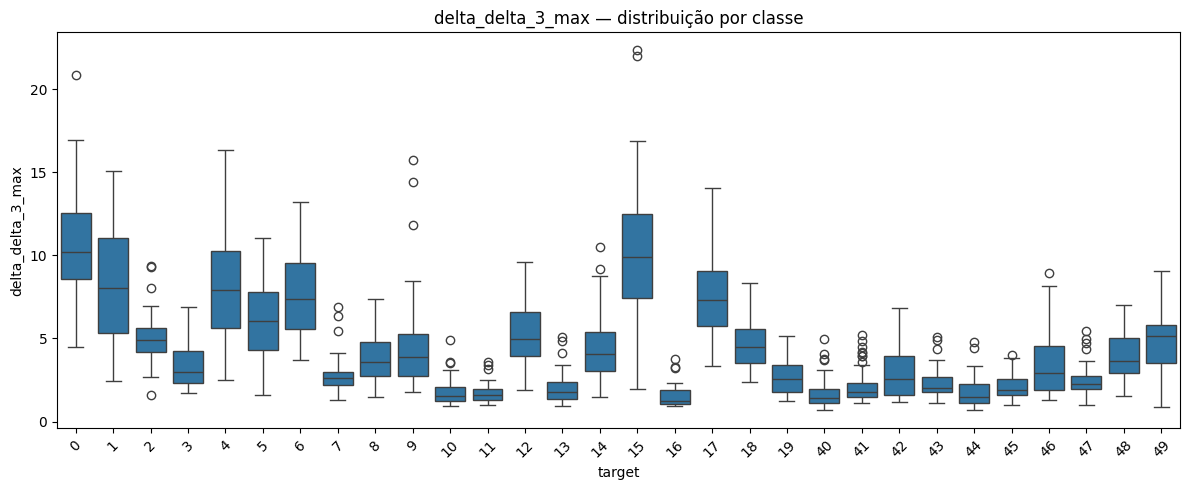

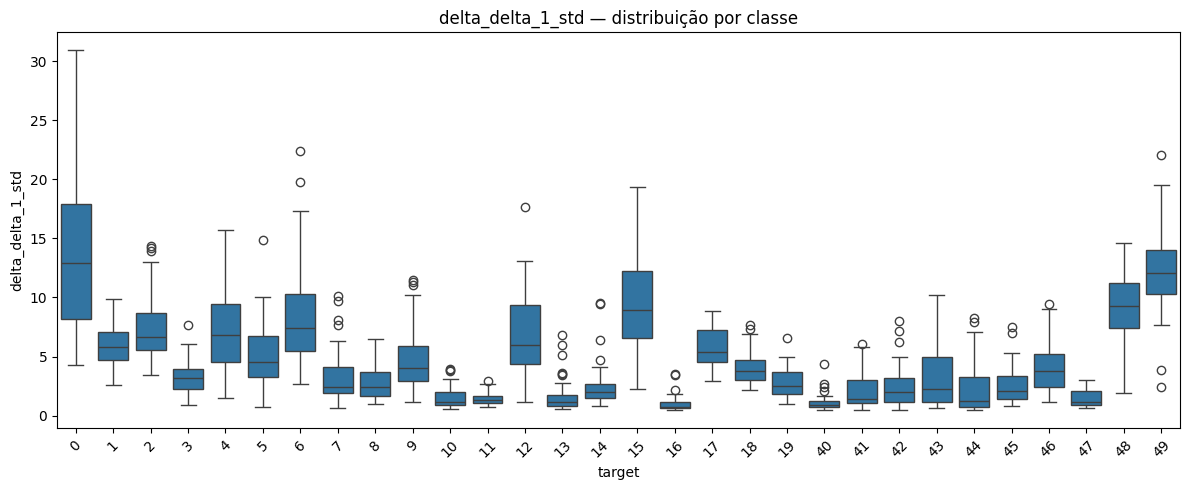

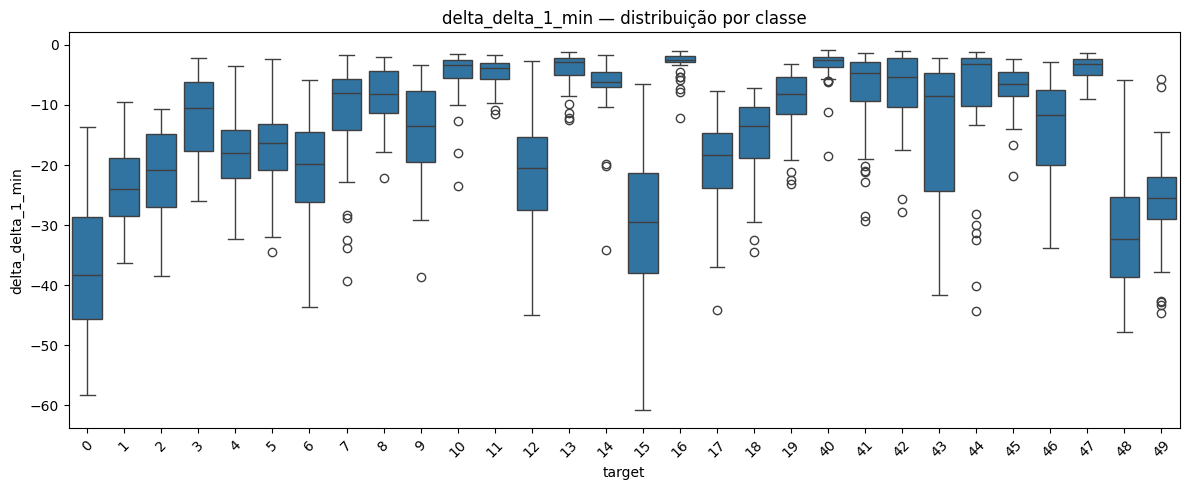

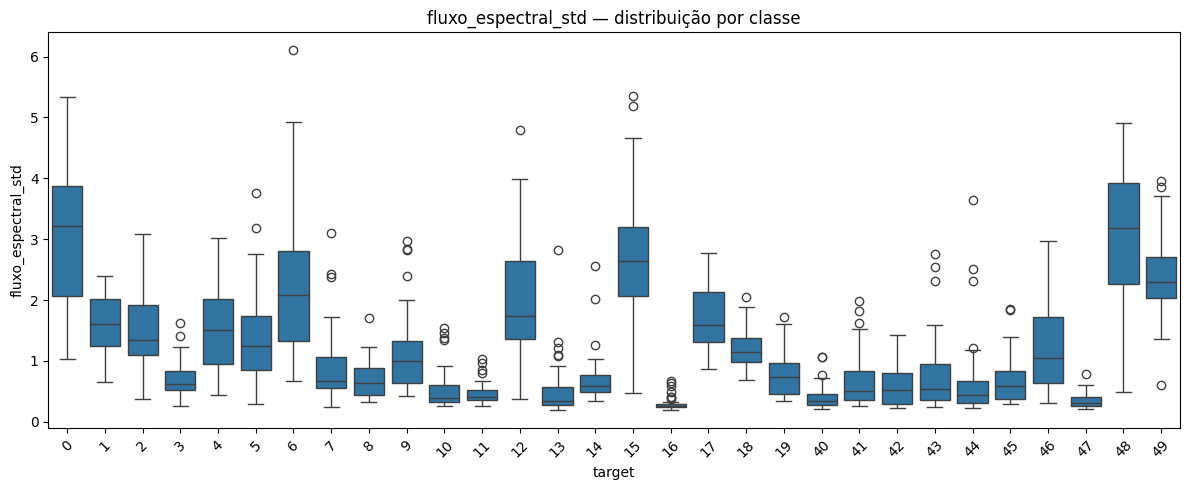

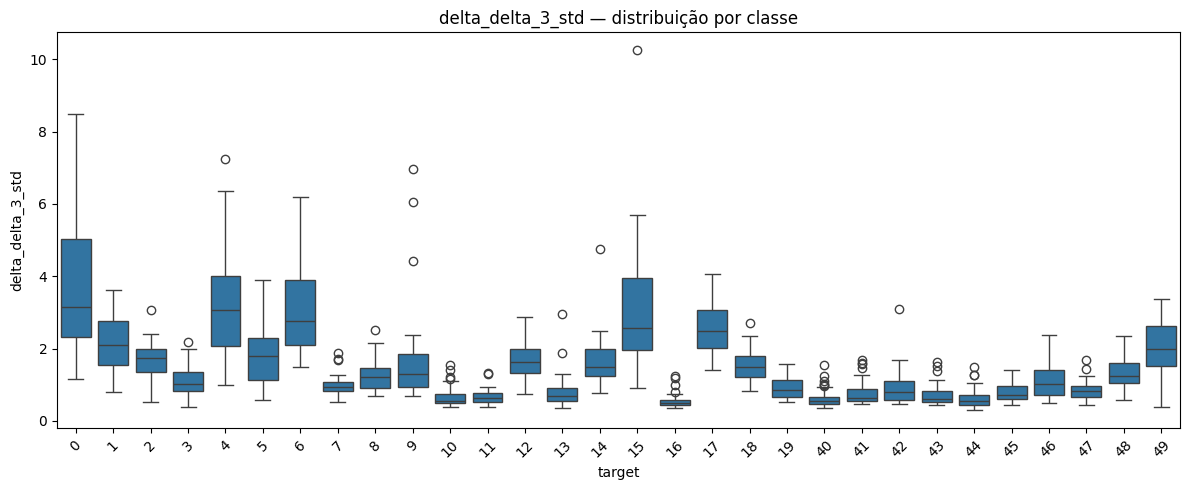

In [16]:
print("TOP C ---------")
visualizar_top_atributos(
    df_C,
    ranking_C,
    n=5
)

### 8. Matriz de Correlação (Pearson) -  Exp C

In [17]:
limiar = 0.80
# Top 30 já ordenados pelo F-score
top_30 = ranking_C.head(30)["atributo"].tolist()

# Correlação dos 30 melhores
matriz_corr = df_C[top_30].corr(method="pearson")
# Começamos com todos os 30
atributos_selecionados = top_30.copy()

# Percorrer os atributos na ordem do F-score
for i in range(len(top_30)):

    atributo_1 = top_30[i]

    # Se já foi removido, pula
    if atributo_1 not in atributos_selecionados:
        continue

    for j in range(i + 1, len(top_30)):
        atributo_2 = top_30[j]

        # Se já foi removido, pula
        if atributo_2 not in atributos_selecionados:
            continue

        correlacao = matriz_corr.loc[atributo_1, atributo_2]

        if abs(correlacao) >= limiar:
            # Como atributo_1 aparece antes no ranking,
            # ele possui F-score maior.
            atributos_selecionados.remove(atributo_2)

print(f"Top 30 inicial: {len(top_30)} atributos")
print(f"Após remover redundâncias: {len(atributos_selecionados)} atributos")

print("\nAtributos finais:")
for i, atributo in enumerate(atributos_selecionados, 1):
    f_score = ranking_C.loc[
        ranking_C["atributo"] == atributo, "F_score"
    ].iloc[0]

    print(f"{i:2d}. {atributo:<40} F Score = {f_score:.2f}")

Top 30 inicial: 30 atributos
Após remover redundâncias: 12 atributos

Atributos finais:
 1. delta_delta_3_max                        F Score = 70.97
 2. delta_delta_1_std                        F Score = 69.05
 3. fluxo_espectral_max                      F Score = 55.08
 4. mfcc_3_std                               F Score = 54.21
 5. delta_1_min                              F Score = 54.03
 6. delta_4_std                              F Score = 54.01
 7. mfcc_3_min                               F Score = 50.44
 8. centroid_max                             F Score = 50.31
 9. delta_delta_2_max                        F Score = 44.95
10. fluxo_espectral_mean                     F Score = 44.43
11. mfcc_1_median                            F Score = 44.04
12. mfcc_5_std                               F Score = 40.43


### 9. Dataset Final e teste de GMM

In [18]:
# Classes normais: 0 a 19
df_normal = df_C[
    df_C["target"].between(0, 19)
].copy()

# Os 12 atributos selecionados
atributos_finais = [
    "delta_delta_3_max",
    "delta_delta_1_std",
    "fluxo_espectral_max",
    "mfcc_3_std",
    "delta_1_min",
    "delta_4_std",
    "mfcc_3_min",
    "centroid_max",
    "delta_delta_2_max",
    "fluxo_espectral_mean",
    "mfcc_1_median",
    "mfcc_5_std"
]

X_normal = df_normal[atributos_finais].copy()

# Remover valores inválidos
X_normal = X_normal.replace([np.inf, -np.inf], np.nan)
X_normal = X_normal.dropna()

# PADRONIZAÇÃO
scaler = StandardScaler()

X_normal_scaled = scaler.fit_transform(X_normal)

print("Áudios normais:", X_normal_scaled.shape[0])
print("Atributos:", X_normal_scaled.shape[1])

Áudios normais: 800
Atributos: 12


In [19]:
resultados_bic = []

for k in range(2, 15):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42,
        reg_covar=1e-3,
        n_init=10
    )

    gmm.fit(X_normal_scaled)

    bic = gmm.bic(X_normal_scaled)

    resultados_bic.append({
        "n_components": k,
        "BIC": bic
    })

df_bic = pd.DataFrame(resultados_bic)

display(df_bic)

,n_components,BIC
0,2,21590.227460
1,3,19825.626631
2,4,18635.032632
3,5,18345.178052
4,6,17926.188541
5,7,17640.963305
6,8,17455.035120
7,9,17353.993302
8,10,17256.110005
9,11,17224.044562


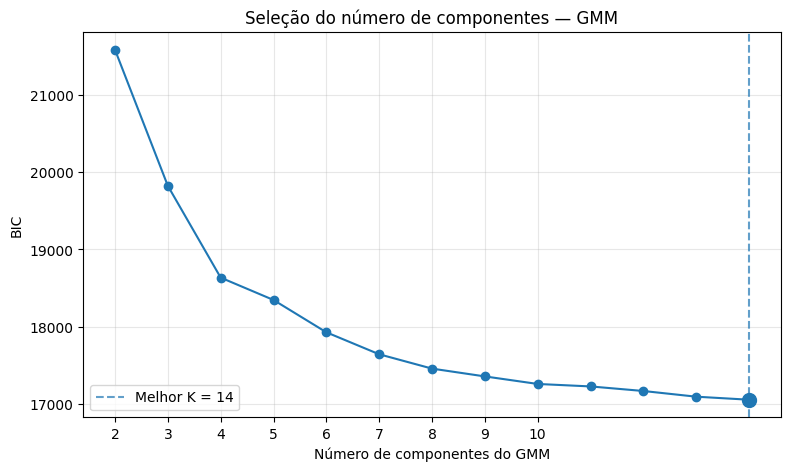

Melhor número de componentes: 14
Menor BIC: 17051.73


In [20]:
# GRÁFICO DO BIC

plt.figure(figsize=(9, 5))

plt.plot(
    df_bic["n_components"],
    df_bic["BIC"],
    marker="o"
)

melhor_k = df_bic.loc[
    df_bic["BIC"].idxmin(),
    "n_components"
]

melhor_bic = df_bic["BIC"].min()

plt.axvline(
    melhor_k,
    linestyle="--",
    alpha=0.7,
    label=f"Melhor K = {melhor_k}"
)

plt.scatter(
    melhor_k,
    melhor_bic,
    s=100,
    zorder=5
)

plt.xlabel("Número de componentes do GMM")
plt.ylabel("BIC")
plt.title("Seleção do número de componentes — GMM")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"Melhor número de componentes: {melhor_k}")
print(f"Menor BIC: {melhor_bic:.2f}")

### 10. GMM: Definição de LogLikelihood e Threshold

In [21]:
from sklearn.mixture import GaussianMixture

# ============================================================
# GMM FINAL — 10 COMPONENTES
# ============================================================

K_FINAL = 10

gmm_normal = GaussianMixture(
    n_components=K_FINAL,
    covariance_type="diag",
    random_state=42,
    reg_covar=1e-3,
    n_init=10
)

gmm_normal.fit(X_normal_scaled)

print("GMM treinado.")
print("Número de componentes:", gmm_normal.n_components)
print("Convergência:", gmm_normal.converged_)
print("Número de iterações:", gmm_normal.n_iter_)

GMM treinado.
Número de componentes: 10
Convergência: True
Número de iterações: 54


In [22]:
# ============================================================
# SCORE DOS ÁUDIOS NORMAIS
# ============================================================

scores_normal = gmm_normal.score_samples(X_normal_scaled)

print("Quantidade de scores:", len(scores_normal))
print("\nPrimeiros 10 scores:")
print(scores_normal[:10])

Quantidade de scores: 800

Primeiros 10 scores:
[-23.34889077  -6.1574061   -2.95235994  -2.68657978  -6.13473937
 -17.91565816 -12.23089149 -13.34093466 -11.65084911 -15.61836423]


In [23]:
df_scores_normal = df_normal.copy()

df_scores_normal["score_gmm"] = scores_normal

display(
    df_scores_normal[
        ["filename", "target", "score_gmm"]
    ].head(5)
)

,filename,target,score_gmm
0,1-100032-A-0.wav,0,-23.348891
1,1-100038-A-14.wav,14,-6.157406
2,1-101296-A-19.wav,19,-2.952360
3,1-101296-B-19.wav,19,-2.686580
4,1-103298-A-9.wav,9,-6.134739


In [24]:
df_scores_normal.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_median,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_median,mfcc_2_min,mfcc_2_max,...,entropia_espectral_max,fluxo_espectral_mean,fluxo_espectral_std,fluxo_espectral_median,fluxo_espectral_min,fluxo_espectral_max,filename,target,category,score_gmm
0,-611.112244,117.399818,-642.974304,-642.974304,-31.522270,3.361105,12.966157,0.000000,0.000000,87.435654,...,NaN,0.352443,2.376412,0.000000,0.0,24.716898,1-100032-A-0.wav,0,dog,-23.348891
1,-178.575439,17.161978,-180.071945,-215.220612,-126.745781,-23.356356,15.433142,-22.000174,-58.251057,9.771303,...,6.113655,1.301244,0.832939,1.075800,0.0,3.651018,1-100038-A-14.wav,14,chirping_birds,-6.157406
2,-405.019348,22.266106,-410.347137,-454.840393,-343.954651,120.540054,22.638435,114.995270,86.732315,187.535095,...,4.516860,0.908821,0.342104,0.893684,0.0,2.808544,1-101296-A-19.wav,19,thunderstorm,-2.952360
3,-379.645355,39.677406,-372.821320,-480.120026,-302.300690,135.552383,34.032024,140.348175,66.976669,195.748398,...,4.358696,0.947267,0.445343,0.848438,0.0,2.949559,1-101296-B-19.wav,19,thunderstorm,-2.686580
4,-100.450356,62.671310,-129.500351,-169.794815,36.854240,78.995445,23.609680,89.209427,20.031935,108.463745,...,5.482761,1.276000,1.442402,0.839021,0.0,8.154843,1-103298-A-9.wav,9,crow,-6.134739


In [25]:
print("Estatísticas dos scores normais:")
print(f"Mínimo:    {np.min(scores_normal):.4f}")
print(f"Percentil 1:  {np.percentile(scores_normal, 1):.4f}")
print(f"Percentil 5:  {np.percentile(scores_normal, 5):.4f}")
print(f"Percentil 10: {np.percentile(scores_normal, 10):.4f}")
print(f"Mediana:     {np.median(scores_normal):.4f}")
print(f"Média:       {np.mean(scores_normal):.4f}")
print(f"Máximo:      {np.max(scores_normal):.4f}")

Estatísticas dos scores normais:
Mínimo:    -39.8328
Percentil 1:  -24.7493
Percentil 5:  -19.9706
Percentil 10: -17.7568
Mediana:     -10.3756
Média:       -9.7448
Máximo:      6.8933


In [26]:
# SCORE DAS ANOMALIAS
# Selecionar apenas as anomalias
df_anomalias = df_C[
    df_C["target"].between(40, 49)
].copy()

# Selecionar os mesmos 12 atributos usados no treinamento
X_anomalias = df_anomalias[atributos_finais].copy()

# Tratar valores inválidos
X_anomalias = X_anomalias.replace([np.inf, -np.inf], np.nan)

mask_validos = X_anomalias.notna().all(axis=1)

X_anomalias = X_anomalias.loc[mask_validos]
df_anomalias = df_anomalias.loc[mask_validos]

# IMPORTANTE:
# usar o MESMO scaler treinado nos dados normais
X_anomalias_scaled = scaler.transform(X_anomalias)

# Calcular log-densidade pelo GMM
scores_anomalias = gmm_normal.score_samples(X_anomalias_scaled)

# Guardar os scores
df_anomalias["score_gmm"] = scores_anomalias

print("Scores das anomalias calculados.")
print(f"Quantidade de anomalias: {len(scores_anomalias)}")

Scores das anomalias calculados.
Quantidade de anomalias: 400


In [27]:
print("Estatísticas dos scores anomalias:")
print(f"Mínimo:    {np.min(scores_anomalias):.4f}")
print(f"Percentil 1:  {np.percentile(scores_anomalias, 1):.4f}")
print(f"Percentil 5:  {np.percentile(scores_anomalias, 5):.4f}")
print(f"Percentil 10: {np.percentile(scores_anomalias, 10):.4f}")
print(f"Mediana:     {np.median(scores_anomalias):.4f}")
print(f"Média:       {np.mean(scores_anomalias):.4f}")
print(f"Máximo:      {np.max(scores_anomalias):.4f}")

Estatísticas dos scores anomalias:
Mínimo:    -31.9770
Percentil 1:  -24.5758
Percentil 5:  -20.6862
Percentil 10: -18.9621
Mediana:     -6.9105
Média:       -8.2004
Máximo:      7.1011


In [28]:
print("=== SCORES NORMAIS ===")
print(f"Mínimo:  {np.min(scores_normal):.4f}")
print(f"Média:   {np.mean(scores_normal):.4f}")
print(f"Mediana: {np.median(scores_normal):.4f}")
print(f"Máximo:  {np.max(scores_normal):.4f}")

print("\n=== SCORES ANOMALIAS ===")
print(f"Mínimo:  {np.min(scores_anomalias):.4f}")
print(f"Média:   {np.mean(scores_anomalias):.4f}")
print(f"Mediana: {np.median(scores_anomalias):.4f}")
print(f"Máximo:  {np.max(scores_anomalias):.4f}")

=== SCORES NORMAIS ===
Mínimo:  -39.8328
Média:   -9.7448
Mediana: -10.3756
Máximo:  6.8933

=== SCORES ANOMALIAS ===
Mínimo:  -31.9770
Média:   -8.2004
Mediana: -6.9105
Máximo:  7.1011


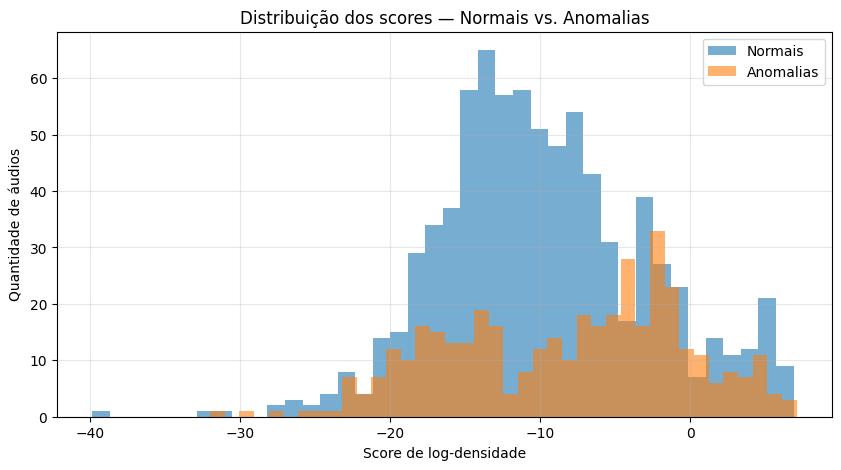

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(
    scores_normal,
    bins=40,
    alpha=0.6,
    label="Normais"
)

plt.hist(
    scores_anomalias,
    bins=40,
    alpha=0.6,
    label="Anomalias"
)

plt.xlabel("Score de log-densidade")
plt.ylabel("Quantidade de áudios")
plt.title("Distribuição dos scores — Normais vs. Anomalias")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
from sklearn.metrics import roc_auc_score

# 0 = normal
# 1 = anomalia
y_score = np.concatenate([
    scores_normal,
    scores_anomalias
])

y_true = np.concatenate([
    np.zeros(len(scores_normal)),
    np.ones(len(scores_anomalias))
])

# Como score menor indica maior chance de anomalia,
# usamos o negativo do score
roc_auc = roc_auc_score(y_true, -y_score)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.4329


In [31]:
df_anomalias["score_gmm"] = scores_anomalias

print(
    df_anomalias
    .groupby("target")["score_gmm"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

        count       mean     median        min       max
target                                                  
40         40  -2.459722  -0.194783 -20.684664  5.406658
45         40  -3.527710  -3.166007 -13.292545  4.572970
41         40  -4.345549  -3.190315 -14.038490  3.941238
47         40  -4.687194  -4.098483 -15.508371  2.749874
44         40  -5.354062  -3.786489 -27.871257  6.423409
46         40  -8.305898  -8.358039 -19.220474  2.552516
43         40  -8.715481  -8.311387 -30.014586  7.101064
42         40 -10.280559  -9.329791 -25.295145  5.440680
48         40 -17.061668 -16.251059 -31.976995 -9.889615
49         40 -17.266479 -17.267859 -23.032359 -9.649547


### 11. Testando outro gmm: PCA + covariance_type=full

In [32]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# =====================================================================
# NOVA ETAPA: Redução de Dimensionalidade com PCA
# Reduzimos de 12D para 3D para viabilizar o uso do modo "full"
# =====================================================================
N_COMPONENTES_PCA = 3
pca = PCA(n_components=N_COMPONENTES_PCA, random_state=42)

# Ajusta o PCA nos dados normais e transforma
X_normal_pca = pca.fit_transform(X_normal_scaled)

# =====================================================================
# CONFIGURAÇÃO DO NOVO GMM (MODO FULL)
# =====================================================================
K_FINAL = 10

gmm_normal = GaussianMixture(
    n_components=K_FINAL,
    covariance_type="full",  # <--- MUDANÇA CRUCIAL: Elipses rotacionadas precisas
    random_state=42,
    reg_covar=1e-3,
    n_init=10,
    max_iter=300,  # Garante tempo para convergir no espaço rotacionado
)

# Treina o GMM usando os dados normais reduzidos pelo PCA
gmm_normal.fit(X_normal_pca)

# =====================================================================
# PROCESSAMENTO DAS ANOMALIAS (MANTENDO SUA LÓGICA)
# =====================================================================
df_anomalias = df_C[df_C["target"].between(40, 49)].copy()

# Selecionar os mesmos 12 atributos usados no treinamento
X_anomalias = df_anomalias[atributos_finais].copy()

# Tratar valores inválidos
X_anomalias = X_anomalias.replace([np.inf, -np.inf], np.nan)
mask_validos = X_anomalias.notna().all(axis=1)

X_anomalias = X_anomalias.loc[mask_validos]
df_anomalias = df_anomalias.loc[mask_validos]

# Aplicar o MESMO scaler e o MESMO PCA treinados nos dados normais
X_anomalias_scaled = scaler.transform(X_anomalias)
X_anomalias_pca = pca.transform(X_anomalias_scaled)  # <--- Transforma anomalias para 3D

# Calcular log-densidade pelo novo GMM
scores_anomalias = gmm_normal.score_samples(X_anomalias_pca)

# Guardar os novos scores no DataFrame de anomalias
df_anomalias["score_gmm"] = scores_anomalias

# =====================================================================
# CÁLCULO AUTOMÁTICO DA NOVA ROC-AUC
# =====================================================================
# Para calcular a ROC-AUC, precisamos também dos scores dos dados normais
scores_normais = gmm_normal.score_samples(X_normal_pca)

# Criar os vetores de rótulos reais (0 para normais, 1 para anomalias)
y_true = np.concatenate(
    [np.zeros(len(scores_normais)), np.ones(len(scores_anomalias))]
)

# Invertemos o sinal dos scores porque a ROC-AUC espera que valores MAIORES
# indiquem a classe positiva (Anomalia). Como menor score = mais anômano, -score resolve.
y_scores = np.concatenate([-scores_normais, -scores_anomalias])

nova_auc = roc_auc_score(y_true, y_scores)
print(f"Antiga ROC-AUC (GMM Diag 12D): 0.4329")
print(f"Nova ROC-AUC (PCA 3D + GMM Full): {nova_auc:.4f}")

Antiga ROC-AUC (GMM Diag 12D): 0.4329
Nova ROC-AUC (PCA 3D + GMM Full): 0.4418


### 12. Testando KDE

In [33]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# =====================================================================
# NOVA ETAPA: Otimização e Treino do KDE
# Vamos achar automaticamente o melhor raio (bandwidth) por validação cruzada
# =====================================================================
params = {'bandwidth': np.logspace(-1, 1, 30)}
grid = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5)
grid.fit(X_normal_pca)

# Extrai o modelo KDE calibrado com o melhor parâmetro estatístico
kde_normal = grid.best_estimator_
print(f"Melhor raio (bandwidth) encontrado para o KDE: {kde_normal.bandwidth:.4f}")

# =====================================================================
# PROCESSAMENTO DAS ANOMALIAS (MANTENDO SUA LÓGICA)
# =====================================================================
df_anomalias = df_C[df_C["target"].between(40, 49)].copy()

# Selecionar os mesmos 12 atributos usados no treinamento
X_anomalias = df_anomalias[atributos_finais].copy()

# Tratar valores inválidos
X_anomalias = X_anomalias.replace([np.inf, -np.inf], np.nan)
mask_validos = X_anomalias.notna().all(axis=1)

X_anomalias = X_anomalias.loc[mask_validos]
df_anomalias = df_anomalias.loc[mask_validos]

# Aplicar o MESMO scaler e o MESMO PCA
X_anomalias_scaled = scaler.transform(X_anomalias)
X_anomalias_pca = pca.transform(X_anomalias_scaled)

# Calcular log-densidade pelo KDE
# score_samples no KDE também retorna o log da densidade (valores negativos)
scores_anomalias = kde_normal.score_samples(X_anomalias_pca)

# Guardar os novos scores no DataFrame de anomalias
df_anomalias["score_kde"] = scores_anomalias

# =====================================================================
# CÁLCULO DA ROC-AUC COM O KDE
# =====================================================================
scores_normais = kde_normal.score_samples(X_normal_pca)

y_true = np.concatenate([np.zeros(len(scores_normais)), np.ones(len(scores_anomalias))])
y_scores = np.concatenate([-scores_normais, -scores_anomalias]) # Menor score = mais anômano

auc_kde = roc_auc_score(y_true, y_scores)
print(f"Antiga ROC-AUC (GMM Diag 12D): 0.4329")
print(f"ROC-AUC Intermediária (PCA 3D + GMM Full): 0.4418")
print(f"Nova ROC-AUC (PCA 3D + KDE): {auc_kde:.4f}")

Melhor raio (bandwidth) encontrado para o KDE: 0.5736
Antiga ROC-AUC (GMM Diag 12D): 0.4329
ROC-AUC Intermediária (PCA 3D + GMM Full): 0.4418
Nova ROC-AUC (PCA 3D + KDE): 0.4059


### 13. Random Forest

In [34]:
df_C.columns

Index(['mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_1_min',
       'mfcc_1_max', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median',
       'mfcc_2_min', 'mfcc_2_max',
       ...
       'entropia_espectral_min', 'entropia_espectral_max',
       'fluxo_espectral_mean', 'fluxo_espectral_std', 'fluxo_espectral_median',
       'fluxo_espectral_min', 'fluxo_espectral_max', 'filename', 'target',
       'category'],
      dtype='object', length=105)

In [35]:
X_normal_scaled

array([[ 1.93327306,  0.83491578,  2.63261139, ..., -1.81790665,
        -2.06181795, -0.37605254],
       [-0.5393996 , -0.72134689, -0.75546513, ...,  0.17445288,
         0.55270684, -0.51674199],
       [-0.86588044, -0.89911803, -0.89096219, ..., -0.64958426,
        -0.74791344, -0.34783001],
       ...,
       [ 0.94177503,  1.28426195,  0.21031908, ...,  1.61315156,
         0.49209107,  0.72150205],
       [-0.41223201, -0.43171031, -0.73627405, ..., -0.37356923,
         0.8701658 , -0.31648147],
       [ 3.02774815,  3.19034742,  2.76528323, ...,  0.79706608,
        -1.43983399,  0.67368195]])

=== RELATÓRIO DE SEPARAÇÃO ACÚSTICA (CLASSE 0) ===
              precision    recall  f1-score   support

           0       0.61      0.62      0.62        40
           1       0.58      0.80      0.67        40
           2       0.64      0.70      0.67        40
           3       0.53      0.57      0.55        40
           4       0.70      0.65      0.68        40
           5       0.42      0.20      0.27        40
           6       0.39      0.30      0.34        40
           7       0.47      0.47      0.47        40
           8       0.49      0.60      0.54        40
           9       0.46      0.28      0.34        40
          10       0.74      0.80      0.77        40
          11       0.84      0.80      0.82        40
          12       0.76      0.80      0.78        40
          13       0.83      0.75      0.79        40
          14       0.78      0.78      0.78        40
          15       0.61      0.62      0.62        40
          16       0.84      0

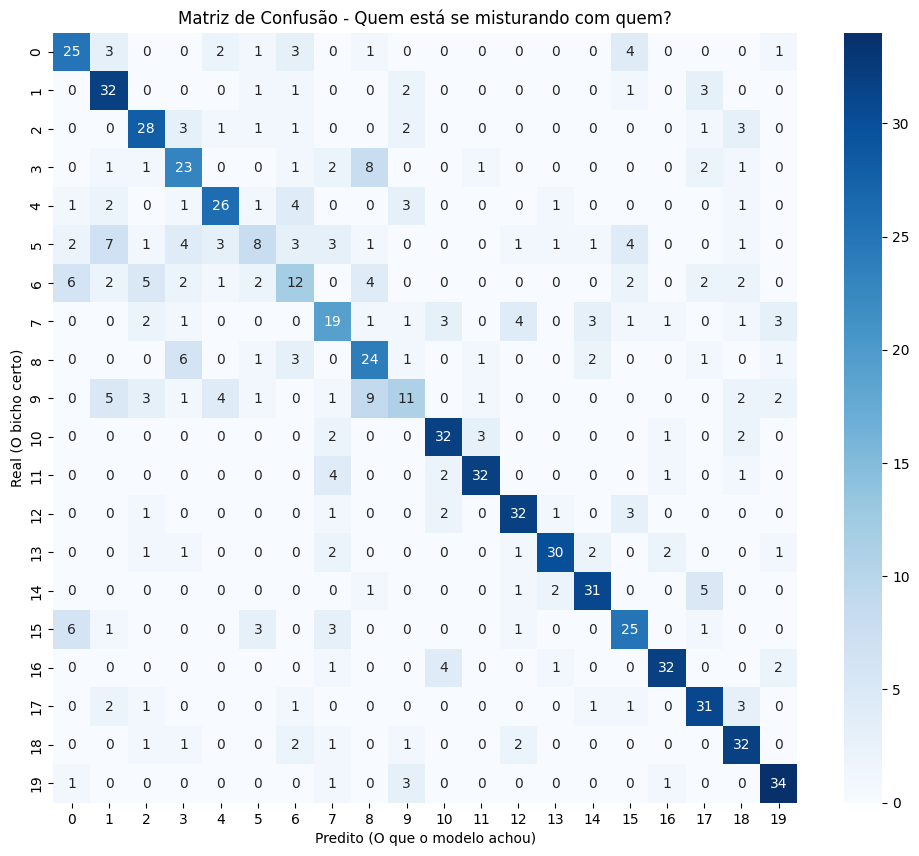

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Recuperar os rótulos originais das 20 classes dos dados normais
# Ajuste o nome da coluna de targets conforme o seu DataFrame original (ex: df_normais['target'])
# Assumindo aqui que você tenha o vetor 'y_normal' com os rótulos de 0 a 19
y_normal = df_C.loc[df_C["target"] < 40, "target"].values

# Garantir que a quantidade de labels bate com suas amostras normalizadas
assert len(X_normal_scaled) == len(y_normal), "O número de amostras e labels não coincide!"

# 2. Configurar o classificador supervisionado
# Usamos 100 árvores e fixamos a semente para reprodutibilidade
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Validação Cruzada Estratificada (5-folds)
# Garante que cada "bicho" tenha representação justa em cada bloco de teste
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(rf_model, X_normal_scaled, y_normal, cv=cv)

# =====================================================================
# DIAGNÓSTICO 1: Relatório de Classificação (Acurácia por Animal)
# =====================================================================
print("=== RELATÓRIO DE SEPARAÇÃO ACÚSTICA (CLASSE 0) ===")
print(classification_report(y_normal, y_pred))

# =====================================================================
# DIAGNÓSTICO 2: Ranking de Importância das 12 Features
# =====================================================================
# Treina no dataset completo apenas para extrair a importância das features
rf_model.fit(X_normal_scaled, y_normal)
importances = rf_model.feature_importances_

df_importancia = pd.DataFrame({
    'Feature': atributos_finais,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

print("\n=== RANKING DE IMPORTÂNCIA DAS FEATURES ===")
print(df_importancia.to_string(index=False))

# =====================================================================
# DIAGNÓSTICO VISUAL: Matriz de Confusão
# =====================================================================
# Se quiser plotar um gráfico para ver quais bichos estão se misturando:
cm = confusion_matrix(y_normal, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Quem está se misturando com quem?')
plt.xlabel('Predito (O que o modelo achou)')
plt.ylabel('Real (O bicho certo)')
plt.show()
